In [ ]:
from google.colab import files
uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv('House Price Prediction Dataset.csv')
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [ ]:
import numpy as np
import pandas as pd
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [ ]:
df.columns = df.columns.str.strip().str.lower()

In [ ]:
df['location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [ ]:
#find the avg house price

avg_price = df['price'].mean()
avg_price

np.float64(537676.855)

In [ ]:
#find the max house price
max_price = df['price'].max()
max_price

999656

In [ ]:
#find the min house price

min_price = df['price'].min()
min_price

50005

In [ ]:
#count total houses
print(df.shape[0])

2000


In [ ]:
#count houses in each location
df['location'].value_counts()

,count
location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [ ]:
#find the avg price of the location

avg_location = df.groupby('location')['price'].mean()
display(avg_location)

,price
location,
Downtown,536059.661290
Rural,538613.943038
Suburban,557416.333333
Urban,518963.548454


In [ ]:
#find the houses with garage

df['garage'].value_counts()

,count
garage,
No,1038
Yes,962


In [ ]:
#find the avg area of house
print(df['area'].mean())

2786.2095


In [ ]:
#find the houses build after 2013
df[df['yearbuilt']>2013].shape[0]


154

In [ ]:
#find the avg price by the by the number of bedrooms
avg_bedroom = df.groupby('bedrooms')['price'].mean()
display(avg_bedroom)

,price
bedrooms,
1,530561.622010
2,545546.521739
3,546977.894089
4,533696.930864
5,532500.124069


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

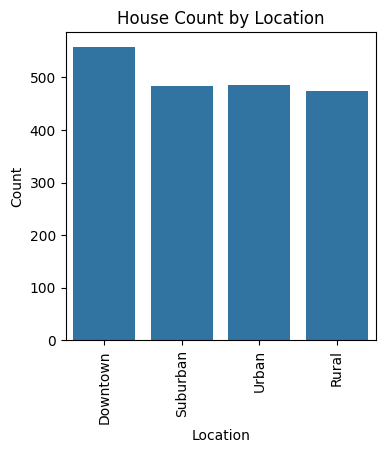

In [ ]:
#house count by the location

plt.figure(figsize=(4,4))
sns.countplot(data=df, x='location')
plt.title('House Count by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

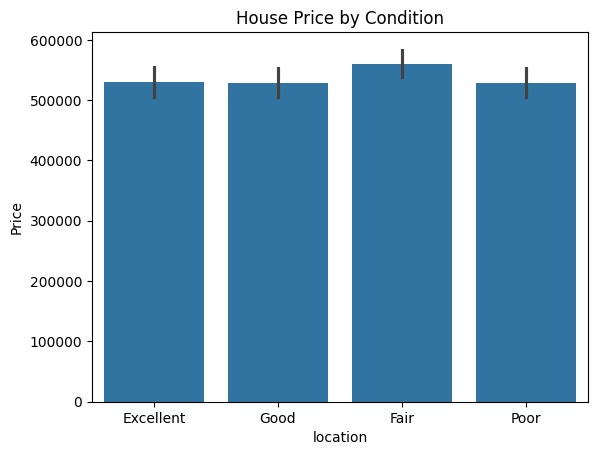

In [ ]:
# house price by condition

sns.barplot(data=df, x='condition', y='price')
plt.title('House Price by Condition')
plt.xlabel('location')
plt.ylabel('Price')
plt.show()


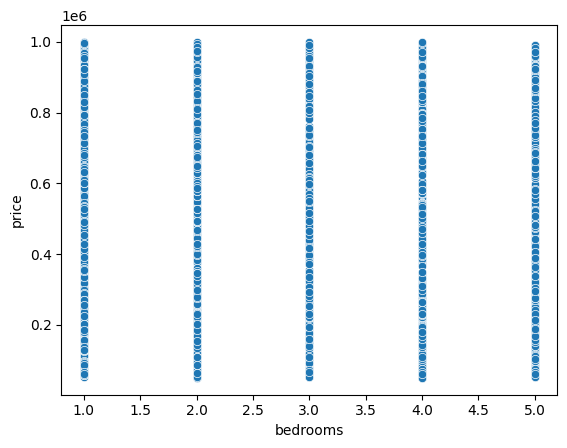

In [ ]:
#  bedroom vs house price

sns.scatterplot(data=df, x='bedrooms', y='price')
plt.show()

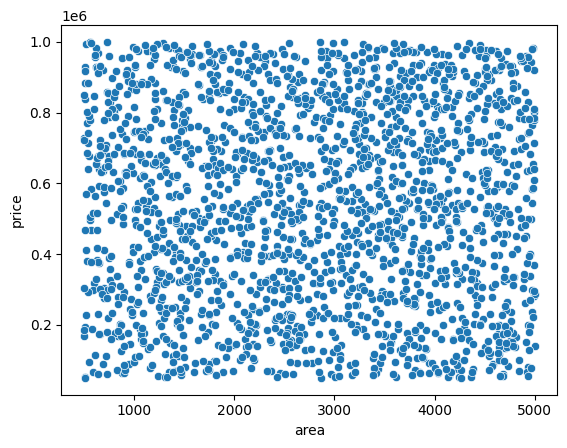

In [ ]:
# area vs price

sns.scatterplot(data=df, x='area', y='price')
plt.show()

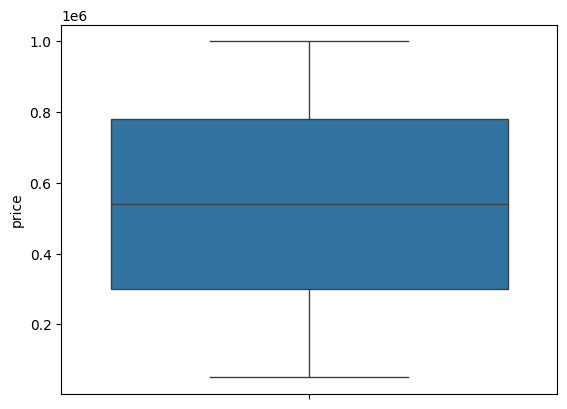

In [ ]:
# price distribution using box plot
sns.boxplot(data=df,y='price')
plt.show()

<Axes: xlabel='bedrooms', ylabel='count'>

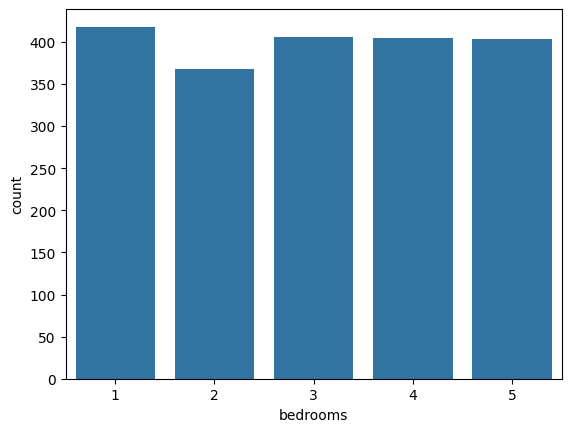

In [ ]:
sns.countplot(data=df,x='bedrooms')

<Axes: xlabel='garage', ylabel='price'>

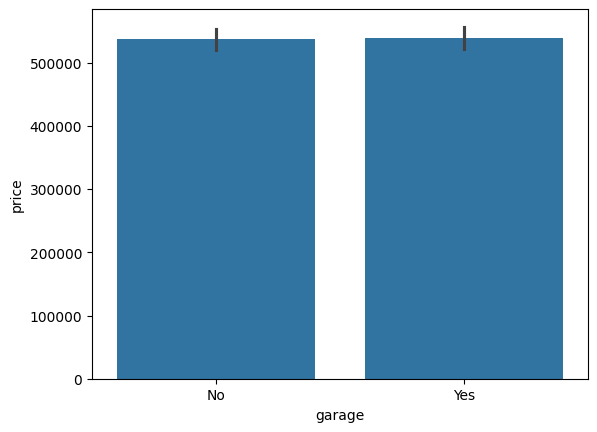

In [ ]:
# garage vs price
sns.barplot(data=df,x='garage',y='price')

<Axes: >

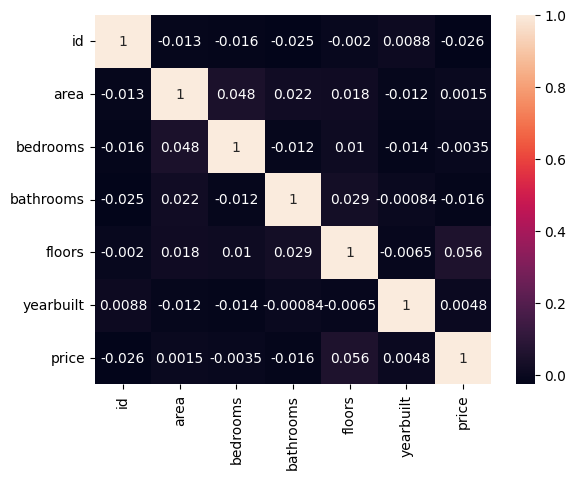

In [ ]:
# correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [ ]:
import pandas as pd
# cleaning the dataset
if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [ ]:
x = df.drop(columns=['price'])
y = df['price']


In [ ]:
x.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'yearbuilt', 'location',
       'condition', 'garage'],
      dtype='object')

In [ ]:
y.name

'price'

In [ ]:
y.shape

(2000,)

In [ ]:
df.shape

(2000, 9)

In [ ]:
#train text split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
x_test.shape


(400, 8)

In [ ]:
x_train.dtypes

,0
area,int64
bedrooms,int64
bathrooms,int64
floors,int64
yearbuilt,int64
location,object
condition,object
garage,object


In [ ]:
y_test.shape

(400,)

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

lr=LinearRegression()

# Identify categorical columns that caused the error
categorical_cols = ['location', 'condition', 'garage']

# Apply one-hot encoding to x_train and x_test
x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Ensure both train and test sets have the same columns after encoding.
# This handles cases where a category might be present in train but not test, or vice-versa,
# by reindexing the test set columns to match the training set and filling missing with 0.
train_cols = x_train_encoded.columns
x_test_encoded = x_test_encoded.reindex(columns=train_cols, fill_value=0)

lr.fit(x_train_encoded,y_train)

LinearRegression()

In [ ]:
y_train_prediction=lr.predict(x_train_encoded)
y_test_prediction=lr.predict(x_test_encoded)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# the reason for using mae , mse , rmse , r2 is that we neve gud
# model by accracy in LinearRegression
#here use error based matrics

mae = mean_absolute_error(y_train,y_train_prediction)
mse = mean_squared_error(y_train,y_train_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_train,y_train_prediction)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2:',r2)

MAE: 237121.9297341298
MSE: 75258376501.24493
RMSE: 274332.60196565214
R2: 0.009856184863687889


In [ ]:
y_train_pred = lr.predict(x_train_encoded)
y_test_pred = lr.predict(x_test_encoded)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Train R2', train_r2)
print('Test R2', test_r2)


# prediction on both train and test data
# so that we can compare the perfomance of our model
# train  prediction - check how well model learned
# test prediction - check how well model generlizes

Train R2 0.009856184863687889
Test R2 -0.006717808430749761


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test,y_test_prediction)
mse = mean_squared_error(y_test,y_test_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_test_prediction)
print('MAE',mae)
print('MSE',mse)
print('RMSE',rmse)
print('R2',r2)

MAE 243241.97758826384
MSE 78321466146.0328
RMSE 279859.72583784326
R2 -0.006717808430749761


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test,y_test_prediction)
mse = mean_squared_error(y_test,y_test_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_test_prediction)
print('MAE',mae)
print('MSE',mse)
print('RMSE',rmse)
print('R2',r2)

MAE 243241.97758826384
MSE 78321466146.0328
RMSE 279859.72583784326
R2 -0.006717808430749761


In [ ]:
# # mae - the avg absolute difference between prediticted and actual hose price .
# we use this cuz its easy to understand , same un
# as price

In [ ]:
# # mae - the avg absolute difference between prediticted and actual hose price .
# # we use this cuz its easy to understand , same un
# # as price
# mse-its squares the errors ,so large mistakes are penalized more
# it highlights bug prediction error, used by many algorithms

# rmsc= it brings the error back to the oroginal price unit , making
# it easier to connnect or interprit ,penalizes large errors

# r2 - re tells us how much of the vaiation in the house prises is
# explained by the model

In [ ]:
new_house=pd.DataFrame({
                       'area':[1360],
                       'bedrooms':[5],
                       'bathrooms':[4],
                       'floors':[3],
                       'yearbuilt':[1970],
                       'location':['Downtown'],
                       'condition':['Excellent'],
                       'garage':['Yes']
                       })

# Identify categorical columns, consistent with previous encoding
categorical_cols = ['location', 'condition', 'garage']

# Apply one-hot encoding to new_house
new_house_encoded = pd.get_dummies(new_house, columns=categorical_cols, drop_first=True)

# Ensure the columns of new_house_encoded match the training columns
# x_train_encoded.columns contains the columns from the training set after encoding
train_cols = x_train_encoded.columns # x_train_encoded is available in the kernel state

# Reindex new_house_encoded to match train_cols, filling missing columns with 0
# This handles cases where new_house might have categories not seen in training, or vice-versa.
new_house_encoded = new_house_encoded.reindex(columns=train_cols, fill_value=0)

# Make prediction using the trained 'lr' model
lr.predict(new_house_encoded)

array([542355.74090577])

In [ ]:
# ridge and lasso regession
# now we will see about preventing overfitting
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_encoded,y_train)

Ridge()

In [ ]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train_encoded,y_train)

Lasso()

<Axes: >

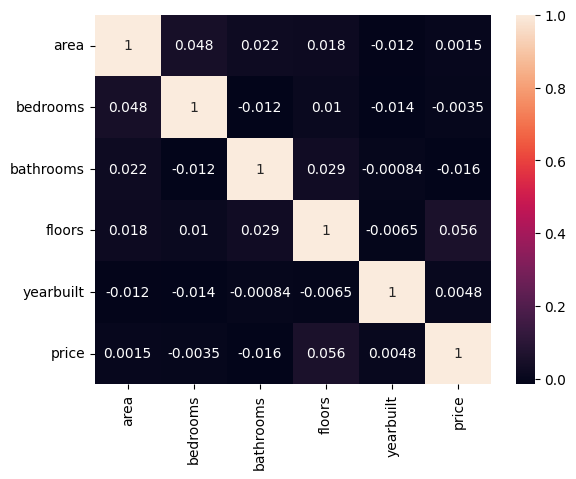

In [ ]:
# correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

<Axes: xlabel='garage', ylabel='price'>

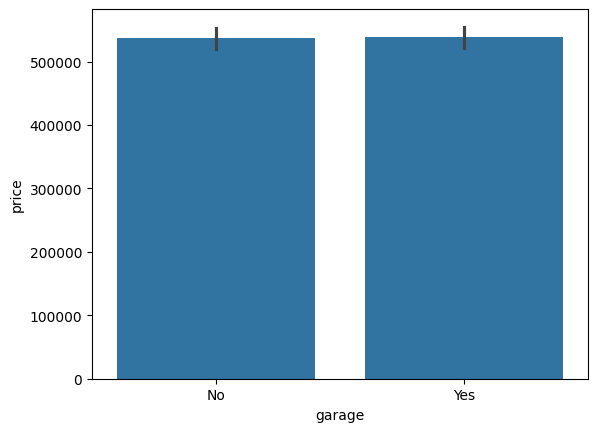

In [ ]:
# garage vs price
sns.barplot(data=df,x='garage',y='price')

<Axes: xlabel='bedrooms', ylabel='count'>

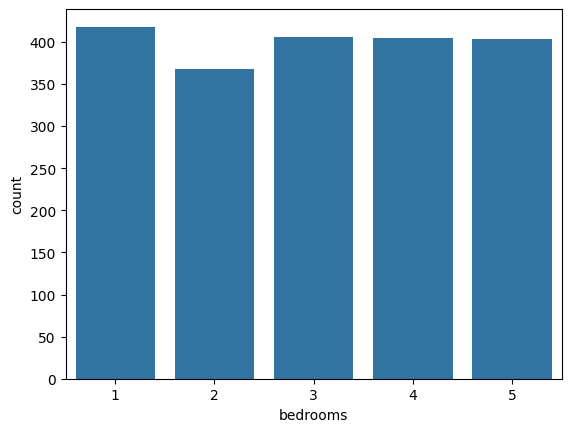

In [ ]:
sns.countplot(data=df,x='bedrooms')

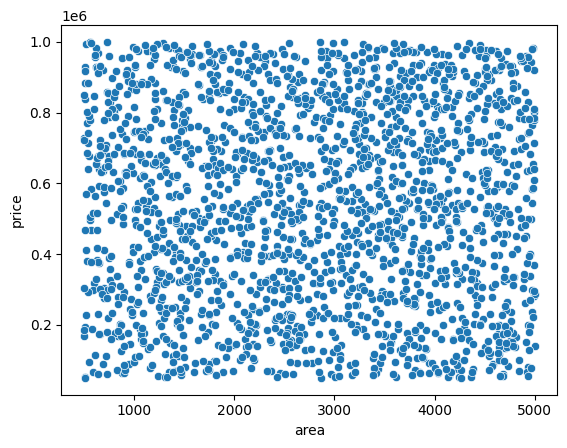

In [ ]:
# area vs price

sns.scatterplot(data=df, x='area', y='price')
plt.show()

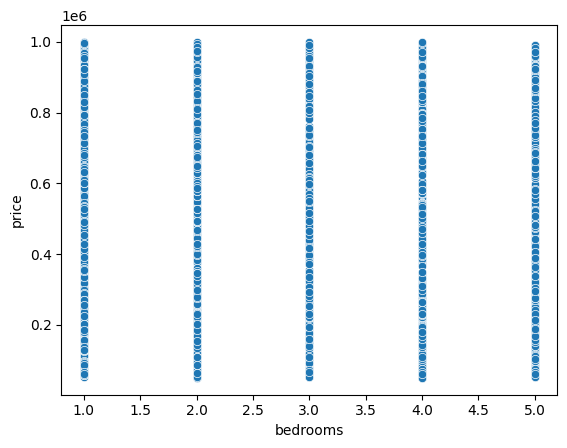

In [ ]:
#  bedroom vs house price

sns.scatterplot(data=df, x='bedrooms', y='price')
plt.show()

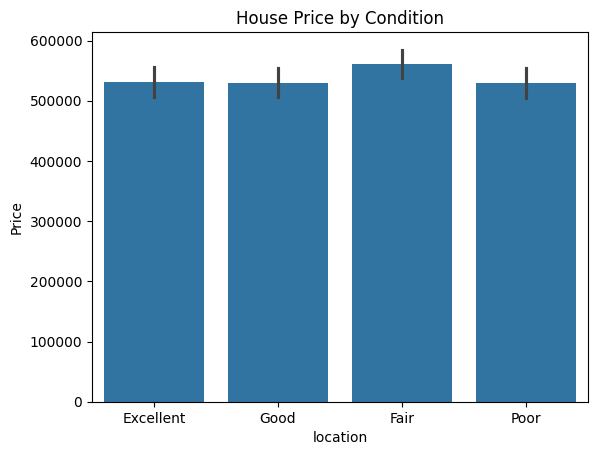

In [ ]:
# house price by condition

sns.barplot(data=df, x='condition', y='price')
plt.title('House Price by Condition')
plt.xlabel('location')
plt.ylabel('Price')
plt.show()

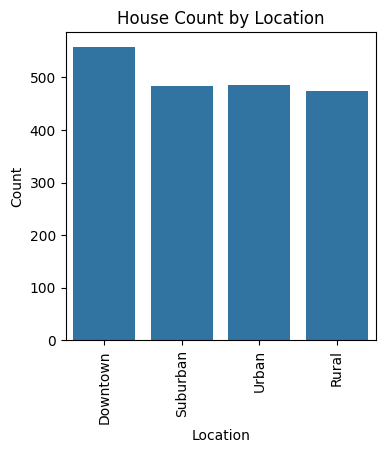

In [ ]:
#house count by the location

plt.figure(figsize=(4,4))
sns.countplot(data=df, x='location')
plt.title('House Count by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# decsion tree model
# we will check with the decision tree model
# and compare the results

# this model learns non-linear relationship
# handels feature interaction better than logistic regression regression